# Mobile Game A/B Test Statistical Analysis

## Objective

Evaluate whether the difference between test groups A and B is statistically significant and commercially meaningful across:

- Payer conversion rate
- Average revenue per user (ARPU)
- Average revenue per paying user (ARPPU)
- Revenue results with and without IQR-flagged observations

In [1]:
# install libraries
%pip install pandas numpy matplotlib seaborn scipy statsmodels


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

sns.set_theme(style="whitegrid")

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}"
    )



In [3]:
Path.cwd()

PosixPath('/Users/zhrs/Documents/Data Analytics Portfolio/Mobile-Game-Retention-AB-Testing/notebooks')

## 1. Data Loading and Initial Inspection

Load the A/B test dataset and verify its structure before conducting statistical analysis.

In [4]:
data_path = (Path.cwd().parent
/ "data"
/ "raw"
/ "ab_test.csv"
)

ab_test = pd.read_csv(
    data_path,
    sep=";"
    )

print(f"Dataset Path: {data_path}")
print(f"Dataset Shape: {ab_test.shape}")

ab_test.head()

Dataset Path: /Users/zhrs/Documents/Data Analytics Portfolio/Mobile-Game-Retention-AB-Testing/data/raw/ab_test.csv
Dataset Shape: (404770, 3)


,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


In [5]:
print("Shape:", ab_test.shape)
print("Columns:", ab_test.columns.to_list())

Shape: (404770, 3)
Columns: ['user_id', 'revenue', 'testgroup']


## 2. Data Validation

Repeat the essential structural and quality checks in Python to confirm that the dataset was loaded correctly and is suitable for statistical analysis.

In [6]:
validation_summary = pd.DataFrame(
    {
        "rows": [len(ab_test)],
        "columns": [ab_test.shape[1]],
        "missing_values": [ab_test.isna().sum().sum()],
        "duplicated_user_id": [
            ab_test["user_id"].duplicated().sum()
            ],
        "minimum_revenue": [ab_test["revenue"].min()],
        "maximum_revenue": [ab_test["revenue"].max()],
        "test_groups": [
            ", ".join(
                sorted(ab_test["testgroup"].unique())
            )
        ],
    }
)

display(ab_test.dtypes.to_frame(name="data_type"))

display(
    validation_summary.T.rename(
        columns={0: "values"}
    )
)

,data_type
user_id,int64
revenue,int64
testgroup,str


,values
rows,404770
columns,3
missing_values,0
duplicated_user_id,0
minimum_revenue,0
maximum_revenue,37433
test_groups,"a, b"


## 3. Descriptive Group Comparison

Create a binary payer indicator and reproduce the principal monetisation metrics before conducting hypothesis tests.

In [7]:
ab_test["is_payer"] = (
    ab_test["revenue"] > 0
).astype(int)

group_summary = (
    ab_test
    .groupby("testgroup")
    .agg(
        participants = ("user_id", "size"),
        total_revenue = ("revenue", "sum"),
        average_revenue_per_user = ("revenue", "mean"),
        paying_users = ("is_payer", "sum"),
        payer_conversion_rate = ("is_payer", "mean"),
        maximum_revenue = ("revenue", "max"),
    )
)

group_summary["payer_conversion_rate_pct"] = (
   group_summary["payer_conversion_rate"] *100
)

group_summary["average_revenue_per_payer"]= (
    group_summary["total_revenue"]
    / group_summary["paying_users"]
)

group_summary[
    [
        "participants",
        "total_revenue",
        "average_revenue_per_user",
        "paying_users",
        "payer_conversion_rate_pct",
        "average_revenue_per_payer",
        "maximum_revenue",
    ]
]

,participants,total_revenue,average_revenue_per_user,paying_users,payer_conversion_rate_pct,average_revenue_per_payer,maximum_revenue
testgroup,,,,,,,
a,202103,5136189,25.4137,1928,0.9540,"2,663.9984",37433
b,202667,5421603,26.7513,1805,0.8906,"3,003.6582",4000


## 4. Payer Conversion Hypothesis Test

A two-proportion z-test is used to compare payer conversion between groups because:

- The outcome is binary: payer or non-payer.
- The test groups are independent.
- Both groups have sufficiently large sample sizes.

### Hypotheses

- **Null hypothesis (H₀):** Groups A and B have equal payer conversion rates.
- **Alternative hypothesis (H₁):** Groups A and B have different payer conversion rates.

The significance level is set at 5% (`α = 0.05`).

In [8]:
payer_counts = np.array(
    [
        group_summary.loc["b", "paying_users"],
        group_summary.loc["a", "paying_users"],
    ]
)

participants_counts = np.array(
    [
        group_summary.loc["b", "participants"],
        group_summary.loc["a", "participants"],
    ]
)

z_statistic, conversion_p_value = proportions_ztest(
    count= payer_counts,
    nobs= participants_counts,
    alternative= "two-sided",
)

conversion_a = group_summary.loc[
    "a", "payer_conversion_rate"
]

conversion_b = group_summary.loc[
    "b", "payer_conversion_rate"
]

conversion_difference_pp = (
    conversion_b - conversion_a
) * 100

relative_conversion_change_pct = (
    conversion_b/ conversion_a -1
) * 100

print(f"Group A Conversion: {conversion_a: .4%}")
print(f"Group B Conversion: {conversion_b: .4%}")
print(
    "Difference (B-A): "
    f"{conversion_difference_pp: .4f} percentage points"
)
print(
    "Relative Change (B vs A): "
    f"{relative_conversion_change_pct: .2f}%"
)
print(f"Z-statistic: {z_statistic: .4f}")
print(f"P-value: {conversion_p_value: .6f}")

Group A Conversion:  0.9540%
Group B Conversion:  0.8906%
Difference (B-A): -0.0633 percentage points
Relative Change (B vs A): -6.64%
Z-statistic: -2.1080
P-value:  0.035029


### Payer Conversion Interpretation

At the 5% significance level, the two-proportion z-test provides evidence that payer conversion differs between the groups (z = −2.1080, p = 0.0350). Group B's conversion rate was 0.8906%, compared with 0.9540% for Group A.

This represents a decrease of 0.0633 percentage points, or 6.64% relative to Group A. Although statistically significant, the absolute difference is small and should be evaluated alongside revenue outcomes before selecting a test-group winner.

In [9]:
conversion_standard_error = np.sqrt(
    conversion_b * (1 - conversion_b)
    / group_summary.loc["b", "participants"]
    +
    conversion_a * (1 - conversion_a)
    / group_summary.loc["a", "participants"]
)

z_critical = stats.norm.ppf(0.975)

conversion_difference = conversion_b - conversion_a

conversion_ci_lower = (
    conversion_difference
    - z_critical * conversion_standard_error
) * 100

conversion_ci_upper = (
    conversion_difference
    + z_critical * conversion_standard_error
) * 100

print(
    "95% CI for conversion difference (B - A): "
    f"[{conversion_ci_lower: .4f}, "
    f"{conversion_ci_upper: .4f}] percentage points"
)

95% CI for conversion difference (B - A): [-0.1222, -0.0044] percentage points


The 95% confidence interval for the conversion difference (B − A) ranges from −0.1222 to −0.0044 percentage points. Because the interval does not contain zero, it supports the conclusion that Group B has a lower payer conversion rate. However, the interval indicates that the absolute commercial effect may range from very small to moderately meaningful.

## 5. Average Revenue per User Hypothesis Test

Average revenue per user (ARPU) is compared using Welch's independent-samples t-test.

### Hypotheses

- **Null hypothesis (H₀):** Mean revenue per user is equal between Groups A and B.
- **Alternative hypothesis (H₁):** Mean revenue per user differs between Groups A and B.

Welch's test is used because the groups have substantially different revenue distributions and variances. The large sample sizes support inference about the group means, but the result will also be checked through bootstrap and outlier-sensitivity analyses.

In [10]:
revenue_a = ab_test.loc[
    ab_test["testgroup"] == "a",
    "revenue",
]

revenue_b = ab_test.loc[
    ab_test["testgroup"] == "b",
    "revenue",
]

revenue_t_statistic, revenue_p_value = stats.ttest_ind(
    revenue_b,
    revenue_a,
    equal_var = False,
)

mean_revenue_a = revenue_a.mean()
mean_revenue_b = revenue_b.mean()

mean_revenue_difference =(
    mean_revenue_b - mean_revenue_a
)

relative_arpu_change_pct = (
    mean_revenue_b / mean_revenue_a - 1
) * 100

print(f"Group A ARPU: {mean_revenue_a: .4f}")
print(f"Group B ARPU: {mean_revenue_b: .4f}")

print(
    "ARPU difference (B -A): "
    f"{mean_revenue_difference: .4f}"
)

print(
    "Relative ARPU change (B vs A): "
    f"{relative_arpu_change_pct: .2f}%"
)

print(f"Welch t-statistic: {revenue_t_statistic: .4f}")
print(f"P-value: {revenue_p_value: .6f}")

Group A ARPU:  25.4137
Group B ARPU:  26.7513
ARPU difference (B -A):  1.3376
Relative ARPU change (B vs A):  5.26%
Welch t-statistic:  0.6235
P-value:  0.532965


### ARPU Test Interpretation

Group B generated 5.26% higher average revenue per user than Group A. However, Welch's t-test found that the difference was not statistically significant (t = 0.6235, p = 0.5330).

Therefore, the null hypothesis of equal mean revenue cannot be rejected at the 5% significance level. The high variability created by Group A's extreme-revenue observations makes the estimated ARPU difference uncertain.

In [11]:
revenue_test_result = stats.ttest_ind(
    revenue_b,
    revenue_a,
    equal_var = False,
)

revenue_confidence_interval= (
    revenue_test_result.confidence_interval(
        confidence_level = 0.95
    )
)

print(
    "95% CI for ARPU difference (B - A): "
    f"[{revenue_confidence_interval.low: .4f}, "
    f"{revenue_confidence_interval.high: .4f}]"
)

95% CI for ARPU difference (B - A): [-2.8672,  5.5423]


The 95% confidence interval for the ARPU difference ranges from −2.8672 to 5.5423 revenue units. Because the interval includes zero, the true effect could favour either group. This agrees with the non-significant Welch test and shows that the observed 5.26% ARPU increase for Group B is uncertain.

## 6. Revenue Outlier Sensitivity Analysis

The primary analysis retains all participants. A sensitivity analysis is conducted by identifying potential high-revenue outliers separately within each group using the IQR rule:

\[
\text{Upper boundary} = Q3 + 1.5 \times IQR
\]

The objective is not to automatically classify unusual users as errors, but to determine how strongly they influence the experimental conclusion.

In [12]:
paying_users = ab_test.loc[
    ab_test["revenue"] > 0
].copy()

revenue_quartiles = (
    paying_users
    .groupby("testgroup")["revenue"]
    .quantile([0.25, 0.75])
    .unstack()
    .rename(
        columns ={
            0.25: "q1",
            0.75: "q3",
        }
    )
)

revenue_quartiles["iqr"] = (
    revenue_quartiles["q3"]
    - revenue_quartiles["q1"]
)

revenue_quartiles["upper_outlier_boundary"] = (
    revenue_quartiles["q3"]
    + 1.5 * revenue_quartiles["iqr"]
)

revenue_quartiles

,q1,q3,iqr,upper_outlier_boundary
testgroup,,,,
a,257.0000,361.0000,104.0000,517.0000
b,"2,513.0000","3,478.0000",965.0000,"4,925.5000"


In [13]:
upper_boundaries = (
    revenue_quartiles["upper_outlier_boundary"]
)

ab_test["upper_outlier_boundary"] = (
    ab_test["testgroup"].map(upper_boundaries)
)

ab_test["is_high_revenue_outlier"] = (
    ab_test["revenue"] > ab_test["upper_outlier_boundary"]
)

ab_test["outlier_revenue"] = np.where(
    ab_test["is_high_revenue_outlier"],
    ab_test["revenue"],
    0,
)

outlier_summary = (
    ab_test
    .groupby("testgroup")
    .agg(
        paying_users = ("is_payer", "sum"),
        high_revenue_outliers = (
            "is_high_revenue_outlier",
            "sum"
            ),
        total_revenue = ("revenue", "sum"),
        outlier_revenue = ("outlier_revenue", "sum"),
        )
)

outlier_summary["outlier_share_of_payers_pct"] = (
    100
    * outlier_summary["high_revenue_outliers"]
    / outlier_summary["paying_users"]
)

outlier_summary["outlier_share_of_revenue_pct"] = (
    100
    * outlier_summary["outlier_revenue"]
    / outlier_summary["total_revenue"]
)

outlier_summary

,paying_users,high_revenue_outliers,total_revenue,outlier_revenue,outlier_share_of_payers_pct,outlier_share_of_revenue_pct
testgroup,,,,,,
a,1928,123,5136189,4590252,6.3797,89.3708
b,1805,0,5421603,0,0.0000,0.0000


The IQR method identified 123 potential high-revenue outliers in Group A and none in Group B. These observations represent 6.38% of Group A's payers but generate 89.37% of its total revenue.

These observations are retained in the primary analysis because unusual values are not necessarily erroneous. The following sensitivity analysis excludes them only to evaluate how dependent the experimental conclusion is on this small segment.

In [14]:
ab_test_no_outliers = ab_test.loc[
    ~ ab_test["is_high_revenue_outlier"]
].copy()

sensitivity_summary = (
    ab_test_no_outliers
    .groupby("testgroup")
    .agg(
        participants = ("user_id", "size"),
        total_revenue = ("revenue", "sum"),
        average_revenue_per_user = ("revenue", "mean"),
        paying_users = ("is_payer", "sum"),
    )
)

sensitivity_summary["payer_conversion_rate_pct"] = (
    100
    * sensitivity_summary["paying_users"]
    / sensitivity_summary["participants"]
)

sensitivity_summary["average_revenue_per_payer"] = (
    sensitivity_summary["total_revenue"]
    / sensitivity_summary["paying_users"]
)

sensitivity_summary

,participants,total_revenue,average_revenue_per_user,paying_users,payer_conversion_rate_pct,average_revenue_per_payer
testgroup,,,,,,
a,201980,545937,2.7029,1805,0.8937,302.4582
b,202667,5421603,26.7513,1805,0.8906,"3,003.6582"


In [15]:
sensitivity_revenue_a = (
    ab_test_no_outliers.loc[
        ab_test_no_outliers["testgroup"] == "a",
        "revenue",
    ]
)

sensitivity_revenue_b = (
    ab_test_no_outliers.loc[
        ab_test_no_outliers["testgroup"] == "b",
    "revenue",
    ]
)

sensitivity_test_result = stats.ttest_ind(
    sensitivity_revenue_b,
    sensitivity_revenue_a,
    equal_var = False,
)

sensitivity_mean_revenue_a = float(
    np.mean(sensitivity_revenue_a)
)

sensitivity_mean_revenue_b = float(
    np.mean(sensitivity_revenue_b)
)

sensitivity_mean_difference = (
    sensitivity_mean_revenue_b
    - sensitivity_mean_revenue_a
)

sensitivity_relative_change_pct = (
    sensitivity_mean_revenue_b
    / sensitivity_mean_revenue_a - 1
) * 100

sensitivity_confidence_interval = (
    sensitivity_test_result.confidence_interval(
        confidence_level = 0.95
    )
)

print(
    "ARPU difference after exclusion (B -A): "
    f"{sensitivity_mean_difference: .4f}"
)

print(
    "Relative change after exclusion (B vs A): "
    f"{sensitivity_relative_change_pct: .2f}%"
)

print(
    "Welch t-test statistic: "
    f"{sensitivity_test_result.statistic: .4f}"
)

print(
    "P-value: "
    f"{sensitivity_test_result.pvalue: .3e}"
)

print(
    "95% CI for ARPU difference: "
    f"[{sensitivity_confidence_interval.low: .4f}, "
    f"{sensitivity_confidence_interval.high: .4f}]"
)

ARPU difference after exclusion (B -A):  24.0484
Relative change after exclusion (B vs A):  889.72%
Welch t-test statistic:  37.4885
P-value:  1.530e-306
95% CI for ARPU difference: [ 22.7911,  25.3057]


### Sensitivity Analysis Interpretation

After excluding 123 IQR-flagged Group A observations, Group B's ARPU exceeded Group A's by 24.0484 revenue units, representing an 889.72% relative increase. This difference was statistically significant (Welch t = 37.4885, p < 0.001), with a 95% confidence interval from 22.7911 to 25.3057.

The contrast with the non-significant primary analysis demonstrates that the revenue conclusion is highly sensitive to a small high-value segment. The flagged observations should not be removed automatically. Their validity and business meaning should be investigated before making a rollout decision.

## 7. Bootstrap Validation of ARPU Difference

Bootstrapping repeatedly resamples participants with replacement and recalculates the ARPU difference. This provides a distribution-based confidence interval without requiring individual revenue values to follow a normal distribution.

In [16]:
full_revenue_a = revenue_a.to_numpy(dtype=float)
full_revenue_b = revenue_b.to_numpy(dtype=float)

def mean_difference(group_b, group_a, axis):
    return (
        np.mean(group_b, axis=axis)
        - np.mean(group_a, axis=axis)
    )

bootstrap_result = stats.bootstrap(
    data = (full_revenue_b, full_revenue_a),
    statistic = mean_difference,
    n_resamples = 1000,
    confidence_level = 0.95,
    alternative = "two-sided",
    method = "percentile",
    vectorized = True,
    paired = False,
    batch = 20,
    rng = np.random.default_rng(42),
)

print(
    "Observed ARPU difference (B -A): "
    f"{mean_revenue_difference: .4f}"
)

print(
    "Bootstrap standard error: "
    f"{bootstrap_result.standard_error: .4f}"
)

print(
    "Bootstrap 95% CI: "
    f"[{bootstrap_result.confidence_interval.low: .4f}, "
    f"{bootstrap_result.confidence_interval.high: .4f}]"
)

Observed ARPU difference (B -A):  1.3376
Bootstrap standard error:  2.2041
Bootstrap 95% CI: [-3.0478,  5.2873]


### Bootstrap Interpretation

Group B's observed ARPU was 1.3376 revenue units higher than Group A's, representing a 5.26% relative increase. However, the bootstrap 95% confidence interval for the difference ranged from -3.0478 to 5.2873 and included zero.

This result supports the Welch t-test conclusion: the full-data ARPU difference is not statistically significant. Therefore, the experiment does not provide sufficient evidence that Group B produces higher average revenue per participant.

The revenue conclusion is highly sensitive to 123 IQR-flagged observations in Group A, which account for 89.37% of that group's revenue. These observations should not be removed automatically. Their validity and business origin should be investigated before making a rollout decision.

## 8. Statistical Results Summary

The following table consolidates the effect size, confidence interval, p-value, and statistical conclusion for each analysis.

In [17]:
statistical_results = pd.DataFrame(
    {
        "analysis": [
            "Payer conversion: B vs A",
            "ARPU: full dataset",
            "ARPU: excluding IQR-flagged observations",
        ],
        "effect": [
            conversion_difference_pp,
            mean_revenue_difference,
            sensitivity_mean_difference,
        ],
        "ci_lower": [
            conversion_ci_lower,
            revenue_confidence_interval.low,
            sensitivity_confidence_interval.low,
        ],
        "ci_upper": [
            conversion_ci_upper,
            revenue_confidence_interval.high,
            sensitivity_confidence_interval.high,
        ],
        "p_value": [
            conversion_p_value,
            revenue_p_value,
            sensitivity_test_result.pvalue,
        ],
        "statistically_significant": [
            conversion_p_value < 0.05,
            revenue_p_value < 0.05,
            sensitivity_test_result.pvalue < 0.05,
        ],
    }
)

statistical_results

,analysis,effect,ci_lower,ci_upper,p_value,statistically_significant
0,Payer conversion: B vs A,-0.0633,-0.1222,-0.0044,0.0350,True
1,ARPU: full dataset,1.3376,-2.8672,5.5423,0.5330,False
2,ARPU: excluding IQR-flagged observations,24.0484,22.7911,25.3057,0.0000,True


In [18]:
statistical_results.insert(
    2,
    "effect_unit",
    [
        "percentage points",
        "revenue units",
        "revenue units",
    ],
)

statistical_results

,analysis,effect,effect_unit,ci_lower,ci_upper,p_value,statistically_significant
0,Payer conversion: B vs A,-0.0633,percentage points,-0.1222,-0.0044,0.0350,True
1,ARPU: full dataset,1.3376,revenue units,-2.8672,5.5423,0.5330,False
2,ARPU: excluding IQR-flagged observations,24.0484,revenue units,22.7911,25.3057,0.0000,True


## 9. Business Recommendation

### Key Findings

- Group B's payer conversion rate was 0.0633 percentage points lower than Group A's. The difference was statistically significant (p = 0.0350; 95% CI: -0.1222 to -0.0044 percentage points).
- Group B's observed ARPU was 1.3376 revenue units higher than Group A's, equivalent to a 5.26% relative increase. However, this difference was not statistically significant in the full dataset (p = 0.5330; 95% CI: -2.8672 to 5.5423).
- The bootstrap analysis supported the full-data ARPU conclusion because its confidence interval also included zero.
- Group A contained 123 IQR-flagged high-revenue observations. These represented 6.38% of Group A's payers but contributed 89.37% of its total revenue.
- After excluding these observations, Group B's ARPU was significantly higher. However, this sensitivity result should not replace the primary full-data result unless the flagged observations are confirmed to be invalid.

### Recommendation

A full rollout of Group B is not currently recommended. Group B produced a statistically significant reduction in payer conversion, while its apparent full-data ARPU improvement was not statistically significant.

Before making a rollout decision, the 123 high-revenue observations in Group A should be investigated to determine whether they represent legitimate high-value purchases, a different revenue scale, duplicated or corrupted transactions, or another data-generation issue.

If the observations are legitimate, the full-data analysis should remain the primary result and the experiment is inconclusive on revenue. If they are confirmed to be invalid, the sensitivity analysis provides strong evidence that Group B improves ARPU.

A follow-up experiment with validated revenue tracking and predefined outlier-handling rules is recommended before implementation.

## 10. Visualisations

### 10.1 Payer Conversion Rate by Test Group

This chart compares the percentage of participants who generated positive revenue in each test group.

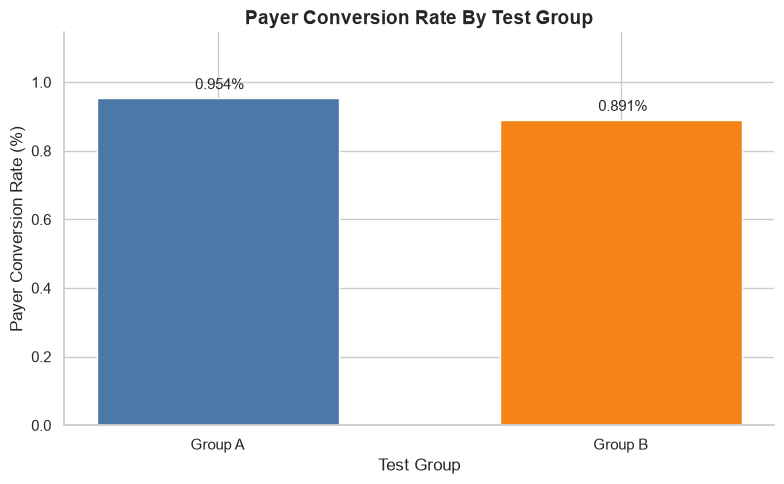

In [19]:
images_path = Path.cwd().parent / "images"
images_path.mkdir(parents=True, exist_ok=True)

conversion_rate_pct = pd.Series(
    {
        "Group A": conversion_a * 100,
        "Group B": conversion_b * 100,
    }
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    conversion_rate_pct.index,
    conversion_rate_pct.values,
    color = ["#4C78A8", "#F58518"],
    width=0.6,

)

ax.bar_label(
    bars,
    labels=[
        f"{value: .3f}%"
        for value in conversion_rate_pct.values
    ],
    padding=4,
    fontsize=11
)

ax.set_title(
    "Payer Conversion Rate By Test Group",
    fontsize=14,
    fontweight= "bold",
)

ax.set_xlabel("Test Group")
ax.set_ylabel("Payer Conversion Rate (%)")

ax.set_ylim(
    0,
    conversion_rate_pct.max() * 1.20,
)

sns.despine()
plt.tight_layout()

figure_path = (
    images_path
    / "payer_conversion_rate_by_group.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 10.2 ARPU: Primary and Sensitivity Analyses

This chart compares average revenue per participant using the complete dataset and after excluding IQR-flagged high-revenue observations. It demonstrates how strongly the revenue conclusion depends on Group A's unusual high-revenue values.

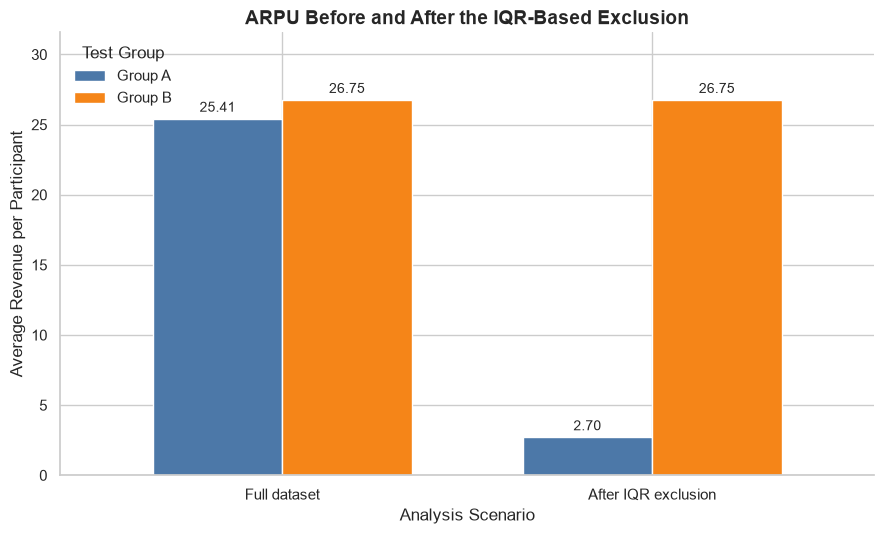

In [20]:
arpu_comparison = pd.DataFrame(
    {
        "Group A": [
            mean_revenue_a,
            sensitivity_mean_revenue_a,
        ],
        "Group B": [
            mean_revenue_b,
            sensitivity_mean_revenue_b,
        ],
    },
        index = [
            "Full dataset",
            "After IQR exclusion",
        ],
)

fig, ax = plt.subplots(figsize=(9, 5.5))

arpu_comparison.plot(
    kind="bar",
    ax=ax,
    color=["#4C78A8", "#F58518"],
    width=0.7,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=10,
    )

ax.set_title(
    "ARPU Before and After the IQR-Based Exclusion",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Analysis Scenario")
ax.set_ylabel("Average Revenue per Participant")
ax.tick_params(axis="x", rotation=0,)

ax.legend(
    title="Test Group",
    frameon=False,
)

ax.set_ylim(
    0,
    arpu_comparison.to_numpy().max() * 1.18
)

sns.despine()
plt.tight_layout()

figure_path = (
    images_path
    / "arpu_primary_vs_sensitivity.png"
    )

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 10.3 Revenue Distribution Among Paying Users

This chart compares positive-revenue observations across the two test groups. A logarithmic revenue axis is used because the values span a wide range. The chart helps reveal the unusual separation between the main revenue patterns and the high-revenue cluster in Group A.

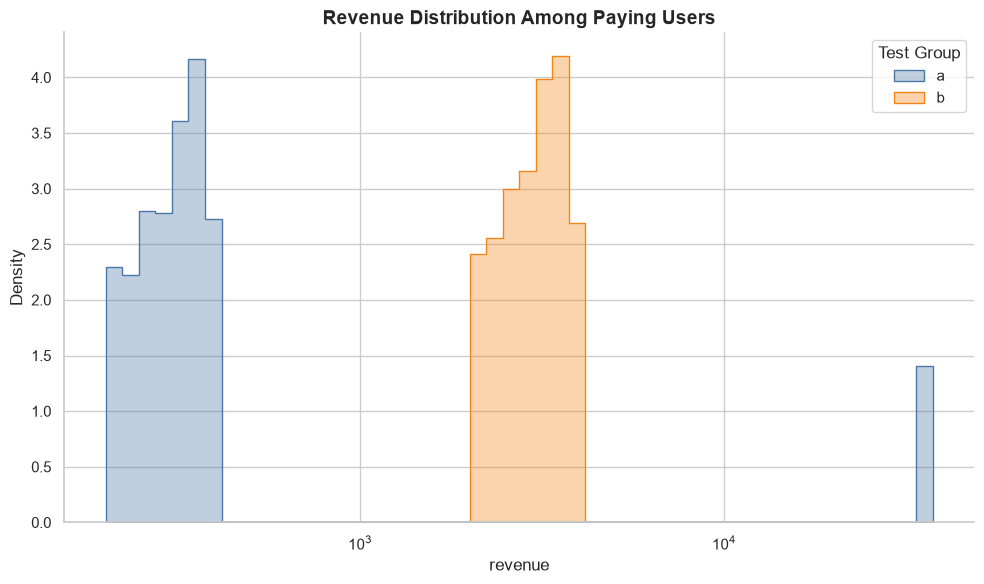

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=paying_users,
    x="revenue",
    hue="testgroup",
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.35,
    log_scale=True,
    palette={
        "a": "#4C78A8",
        "b": "#F58518",
    },
    ax=ax,
)

ax.set_title(
    "Revenue Distribution Among Paying Users",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel=("Revenue per Paying Users - Logarithmic Scale")
ax.set_ylabel=("Density")

legend=ax.get_legend()
if legend is not None:
    legend.set_title("Test Group")

sns.despine()
plt.tight_layout()

figure_path= (
    images_path
    / "payer_revenue_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 10.4 Revenue Composition by Outlier Status

This 100% stacked bar chart shows the share of each test group's revenue generated by IQR-flagged and non-flagged observations. It highlights the concentration of Group A's revenue in a small number of unusually high-revenue observations.

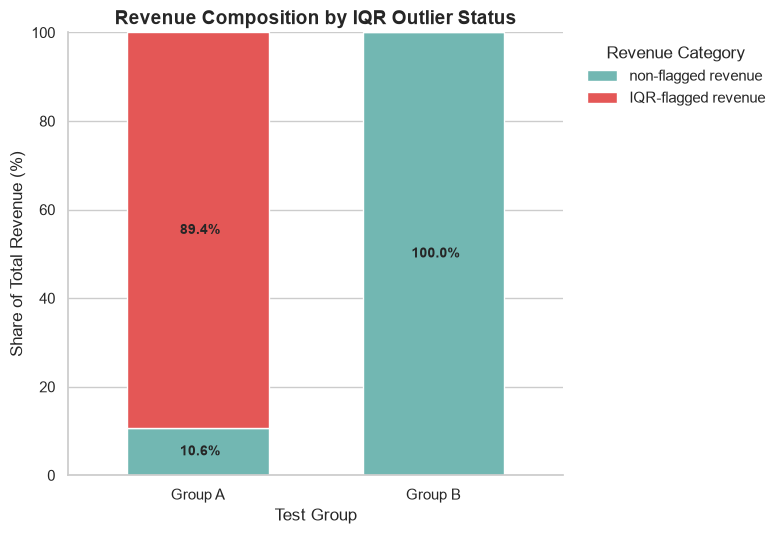

In [22]:
revenue_composition_pct= pd.DataFrame(
    {
        "non-flagged revenue":(
            100
            - outlier_summary[
        "outlier_share_of_revenue_pct"
         ]
        ),
        "IQR-flagged revenue":(
            outlier_summary["outlier_share_of_revenue_pct"
            ]
        ),
    }
)

revenue_composition_pct.index = [
    "Group A",
    "Group B",
]

fig, ax = plt.subplots(figsize=(8, 5.5))

revenue_composition_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#72B7B2", "#E45756"],
    width=0.6,
)

for container in ax.containers:
    labels= [
        f"{value: .1f}%" if value >= 1 else ""
        for value in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=10,
        fontweight="bold",
)

ax.set_title(
    "Revenue Composition by IQR Outlier Status",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Test Group")
ax.set_ylabel("Share of Total Revenue (%)")
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0, 100)

ax.legend(
    title= "Revenue Category",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

sns.despine()
plt.tight_layout()

figure_path = (
    images_path
    / "revenue_composition_by_outlier_status.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 10.5 Day 0–30 Retention Curve

The retention curve reports exact-day retention: the percentage of eligible registered users who authenticated on each specific day after registration. Eligibility is adjusted for right-censoring so users are included only when the dataset contains enough observation time for that retention day.

In [23]:
outputs_path = Path.cwd().parent / "outputs"

retention_curve_path = (
    outputs_path
    / "retention_curve.csv"
)

retention_curve = pd.read_csv(
    retention_curve_path
)

print("Shape: ", retention_curve.shape)
print("Columns: ", retention_curve.columns.tolist())
print(
    "Missing Values: ",
    retention_curve.isna().sum().sum()
)

retention_curve.head()

Shape:  (31, 4)
Columns:  ['day_number', 'eligible_users', 'retained_users', 'retention_rate_pct']
Missing Values:  0


,day_number,eligible_users,retained_users,retention_rate_pct
0,0,1000000,1000000,100.0000
1,1,998952,20071,2.0100
2,2,997311,40997,4.1100
3,3,995673,46338,4.6500
4,4,994037,52258,5.2600


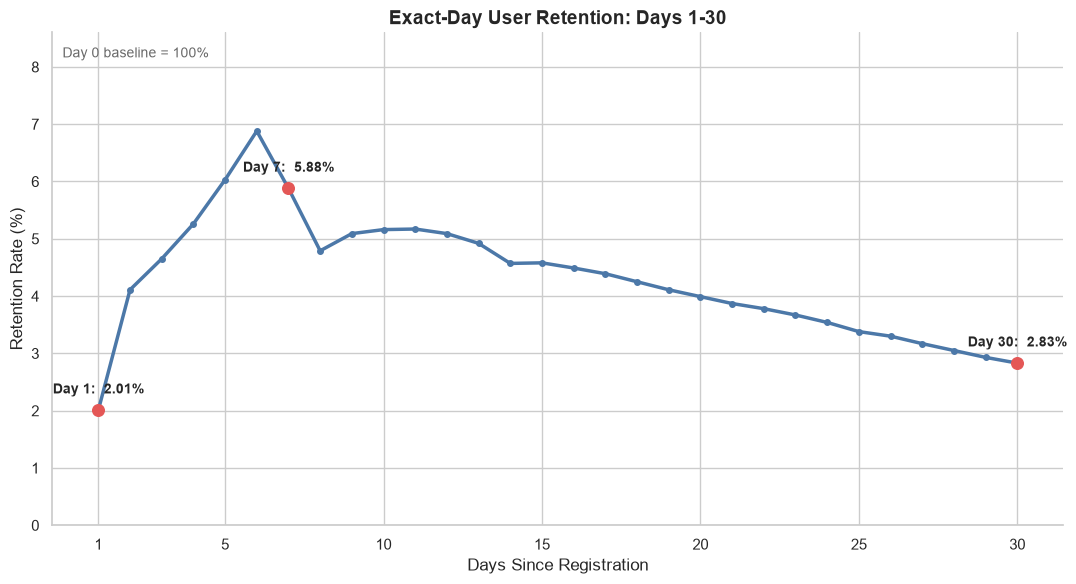

In [24]:
retention_days_1_to_30 = retention_curve.loc[
    retention_curve["day_number"] > 0
].copy()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    retention_days_1_to_30["day_number"],
    retention_days_1_to_30["retention_rate_pct"],
    color= "#4C78A8",
    linewidth=2.5,
    marker="o",
    markersize=4,
)

key_days = [1, 7, 30]

for day in key_days:
    rate = retention_curve.loc[
        retention_curve["day_number"] == day,
        "retention_rate_pct",
    ].iloc[0]

    ax.scatter(
        day,
        rate,
        color= "#E45756",
        s=70,
        zorder=3,
    )

    ax.annotate(
        f"Day {day}: {rate: .2f}%",
        xy=(day, rate),
        xytext = (0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title(
    "Exact-Day User Retention: Days 1-30",
    fontsize=14,
    fontweight="bold",
)

ax.text(
    0.01,
    0.97,
    "Day 0 baseline = 100%",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    color="dimgray"
)

ax.set_xlabel("Days Since Registration")
ax.set_ylabel("Retention Rate (%)")

ax.set_xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

ax.set_ylim(
    0,
    retention_days_1_to_30[
        "retention_rate_pct"
    ].max() * 1.25,
)

sns.despine()
plt.tight_layout()

figure_path = (
    images_path
    / "day_1_to_30_retention_curve.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 10.6 Monthly Cohort Retention Trends

Monthly cohort analysis compares users based on their registration month. Day 1, Day 7, and Day 30 rates use only users with sufficient observation time for the relevant retention window.

In [25]:
cohort_retention_path =(
    outputs_path
    / "monthly_cohort_retention.csv"
)

cohort_retention = pd.read_csv(
    cohort_retention_path,
    parse_dates =["cohort_month"],
)

print("Shape: ", cohort_retention.shape)
print("Columns: ", cohort_retention.columns.tolist())
print(
    "Missing values by column:"
)
print(
    cohort_retention.isna().sum()
)

cohort_retention.tail()

Shape:  (33, 11)
Columns:  ['cohort_month', 'cohort_size', 'eligible_day_1_users', 'retained_day_1_users', 'day_1_retention_rate_pct', 'eligible_day_7_users', 'retained_day_7_users', 'day_7_retention_rate_pct', 'eligible_day_30_users', 'retained_day_30_users', 'day_30_retention_rate_pct']
Missing values by column:
cohort_month                 0
cohort_size                  0
eligible_day_1_users         0
retained_day_1_users         0
day_1_retention_rate_pct     0
eligible_day_7_users         0
retained_day_7_users         0
day_7_retention_rate_pct     0
eligible_day_30_users        0
retained_day_30_users        0
day_30_retention_rate_pct    1
dtype: int64


,cohort_month,cohort_size,eligible_day_1_users,retained_day_1_users,day_1_retention_rate_pct,eligible_day_7_users,retained_day_7_users,day_7_retention_rate_pct,eligible_day_30_users,retained_day_30_users,day_30_retention_rate_pct
28,2020-05-01,41159,41159,781,1.9000,41159,2409,5.8500,41159,1249,3.0300
29,2020-06-01,41880,41880,815,1.9500,41880,2395,5.7200,41880,1187,2.8300
30,2020-07-01,45502,45502,924,2.0300,45502,2646,5.8200,45502,1295,2.8500
31,2020-08-01,47882,47882,969,2.0200,47882,2866,5.9900,36856,1018,2.7600
32,2020-09-01,36540,35492,731,2.0600,25685,1480,5.7600,0,0,NaN


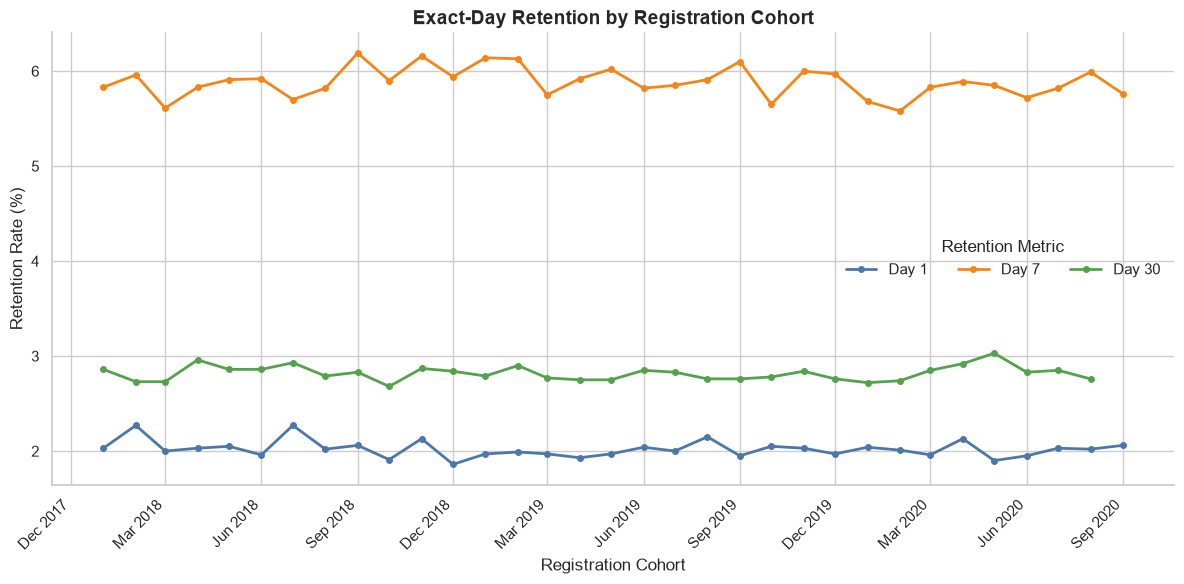

In [26]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    cohort_retention["cohort_month"],
    cohort_retention["day_1_retention_rate_pct"],
    label= "Day 1",
    color= "#4C78A8",
    linewidth=2,
    marker="o",
    markersize=4,
)

ax.plot(
    cohort_retention["cohort_month"],
    cohort_retention["day_7_retention_rate_pct"],
    label="Day 7",
    linewidth=2,
    color= "#F58518",
    marker="o",
    markersize=4,
)

ax.plot(
    cohort_retention["cohort_month"],
    cohort_retention["day_30_retention_rate_pct"],
    label="Day 30",
    linewidth=2,
    color= "#54A24B",
    marker="o",
    markersize=4,
)

ax.set_title(
    "Exact-Day Retention by Registration Cohort",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Registration Cohort")
ax.set_ylabel("Retention Rate (%)")

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

ax.legend(
    title= "Retention Metric",
    frameon=False,
    ncol=3,
)

sns.despine()
plt.tight_layout()

figure_path = (
    images_path
    / "monthly_cohort_retention_trends.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Retention Findings

- Exact Day-1 retention was 2.01%, indicating substantial user loss immediately after registration.
- Retention increased after Day 1 and peaked at 6.88% on Day 6 before generally declining.
- Exact Day-7 retention was 5.88%, while exact Day-30 retention was 2.83%.
- Day-7 retention being higher than Day-1 retention is possible because these are exact-day measures rather than cumulative retention. A user active on Day 7 was not necessarily active on Day 1.
- Monthly cohort retention remained broadly stable between 2018 and 2020. Day-1 retention was approximately 1.86%–2.27%, Day-7 retention was 5.58%–6.19%, and Day-30 retention was 2.68%–3.03%.
- The September 2020 cohort had no eligible Day-30 users because the dataset ended before a complete 30-day observation period was available.

### Retention Recommendations

The strongest opportunity is improving early user engagement, particularly during the first day after registration. The increase toward Days 6–7 should also be investigated to determine whether it reflects scheduled rewards, notifications, weekly gameplay patterns, or another product mechanism.

Future analysis would benefit from additional product-event data, such as sessions, game levels, notifications, acquisition channels, and device characteristics. The available authentication data can describe when users returned but cannot establish why they returned.

## 12. Export Analytical Outputs

The principal A/B testing summaries and statistical results are exported as CSV files for reproducibility and use in reporting.

In [27]:
group_summary.to_csv(
    outputs_path / "ab_test_group_summary.csv",
    index=True,
    index_label="testgroup",
)

revenue_quartiles.to_csv(
    outputs_path / "payer_revenue_quartiles.csv",
    index=True,
    index_label="testgroup",
)

outlier_summary.to_csv(
    outputs_path / "outlier_revenue_summary.csv",
    index=True,
    index_label="testgroup",
)

sensitivity_summary.to_csv(
    outputs_path / "sensitivity_analysis_summary.csv",
    index= True,
    index_label="testgroup",
)

statistical_results.to_csv(
    outputs_path / "statistical_test_results.csv",
    index=False,
)

exported_csv_files = sorted(
    path.name
    for path in outputs_path.glob("*.csv")
)

print("CSV files in the outputs folder:")

for file_name in exported_csv_files:
    print("-", file_name)

CSV files in the outputs folder:
- ab_test_group_summary.csv
- monthly_cohort_retention.csv
- outlier_revenue_summary.csv
- payer_revenue_quartiles.csv
- retention_curve.csv
- sensitivity_analysis_summary.csv
- statistical_test_results.csv
